In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!cp -r "/content/drive/MyDrive/Vietnamese ID Card" "/content/dataset"

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.6 MB/s eta 0:00:00


In [ ]:
!ls /content/dataset/

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [7]:
!yolo task=detect mode=train model=yolov9c.pt data=/content/dataset/data.yaml epochs=20 imgsz=640 batch=16

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9c.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0

In [8]:
!pip install vietocr

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.9/133.9 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 124.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.4/299.4 kB 33.0 MB/s eta 0:00:00
  Created wheel for gdown: filename=gdown-4.4.0-py3-none-any.whl size=14845 sha256=8ab5261c530a15baa7f76382fd074b912aaefaadb4e18687f05eac4659de2772
  Stored in directory: /root/.cache/pip/wheels/cc/dd/9e/edc126b0a309c8ceb1a4f52f30aa1d95b5fad66c02f314fed5
  Created wheel for prefetch-generator: filename=prefetch_generator-1.0.1-py3-none-any.whl size=3941 sha256=58f3b570e81df39f68672cd18c4b8c30b8cd4e0e38ed6f09bdc18801036ab590
  Stored in directory: /root/.cache/pip/wheels/89/bf/65/33c494556b4a8a98f0e

Model weight /tmp/vgg_seq2seq.pth exsits. Ignore download!

image 1/1 /content/test.jpg: 480x640 2 current_places, 1 dob, 1 expire_date, 1 gender, 1 id, 1 name, 1 nationality, 1 origin_place, 39.5ms
Speed: 2.5ms preprocess, 39.5ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)
--- KẾT QUẢ ---
[NATIONALITY]: Việt Nam


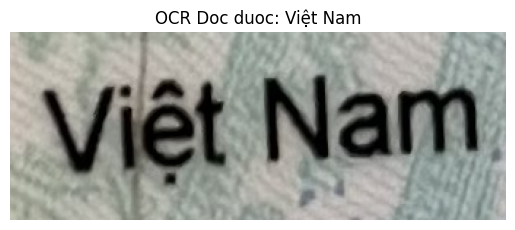

[ID]: 001204014664


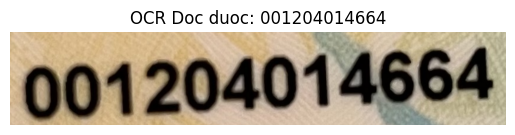

[CURRENT_PLACE]: 218C Đội Cấn


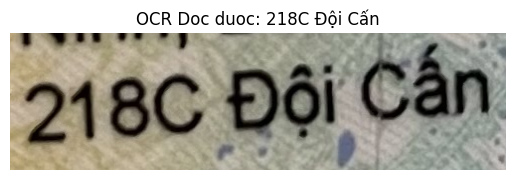

[DOB]: 09/09/2004


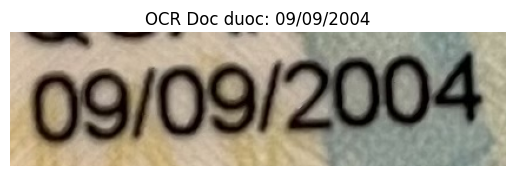

[GENDER]: Nam


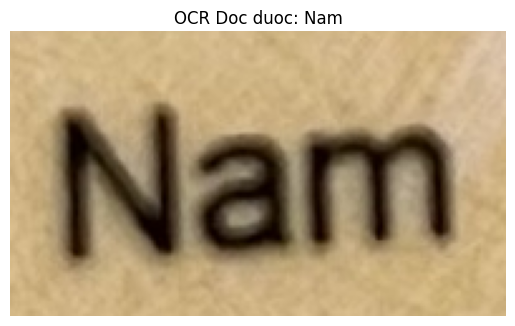

[NAME]: NGUYỄN MINH QUÂN


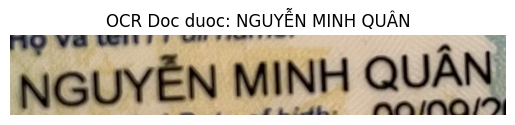

[CURRENT_PLACE]: Liễu Giai, Ba Đình, Hà Nội


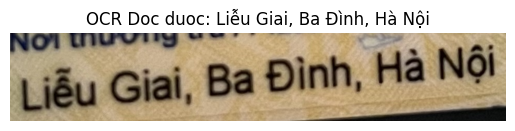

[EXPIRE_DATE]: 09/09/2029


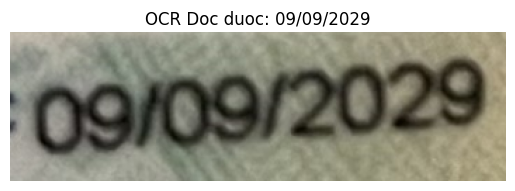

[ORIGIN_PLACE]: Quố quân (Place đương phố Bắc Ninh, Bắc Ninh


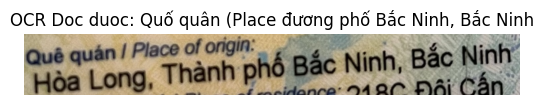

In [6]:
import cv2
import re
from PIL import Image
import matplotlib.pyplot as plt
from ultralytics import YOLO
from vietocr.tool.predictor import Predictor
from vietocr.tool.config import Cfg
def clean_extracted_data(class_name, text):
    text = text.strip()

    if class_name == 'id_number':
        text = re.sub(r'\D', '', text)

    elif class_name == 'dob':
        text = text.replace('-', '/').replace('.', '/')

    elif class_name == 'name':
        text = text.upper()

    return text

yolo_model = YOLO('/content/runs/detect/train2/weights/best.pt')

config = Cfg.load_config_from_name('vgg_seq2seq')
config['device'] = 'cuda:0'
config['cnn']['pretrained'] = False
ocr_model = Predictor(config)

image_path = '/content/test.jpg'
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_height, img_width, _ = img.shape

results = yolo_model(image_path)

print("--- KẾT QUẢ ---")
for box in results[0].boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    class_id = int(box.cls[0])
    class_name = yolo_model.names[class_id]

    padding = 9
    x1 = max(0, x1 - padding)
    y1 = max(0, y1 - padding)
    x2 = min(img_width, x2 + padding)
    y2 = min(img_height, y2 + padding)

    cropped_img = img_rgb[y1:y2, x1:x2]
    pil_img = Image.fromarray(cropped_img)

    raw_text = ocr_model.predict(pil_img)

    final_text = clean_extracted_data(class_name, raw_text)

    print(f"[{class_name.upper()}]: {final_text}")

    plt.imshow(cropped_img)
    plt.title(f"OCR Doc duoc: {final_text}")
    plt.axis('off')
    plt.show()

In [3]:
!pip install gradio
import gradio as gr